# Blender-vs-CT decomposition gap — systematic investigation

*(Notebook generated by Claude, 2026-07-02. All experiments run on the same data used by `3dfront_ct.ipynb`.)*

**Problem.** Decomposing the **CT-SH-rendered** dataset (`results/3dfront-dataset-sh`) works well
(roughness RMSE → ~0.1, albedo scale ≈ 1), but decomposing the **Blender-rendered** dataset
(`results/3dfront-dataset-env[...]`, rendered from the *same* SH lights) gives much higher loss,
poor intrinsics, and albedo scale drifting far from 1.
**User hypothesis:** numerical issues at low roughness despite EXR + float64.

## Pipeline recap (from reading the code)

Both datasets use the **same 128 SH lights** from `results/ref_sh_lighting/sh_iii.npy`
(already normalized so the rectified env-map peak = 1). For light *i*:

| | CT dataset (`3dfront-dataset-sh`) | Blender dataset (`E:\...\1\env_i.*`) |
|---|---|---|
| geometry | proxy: camera (0,0,2), fragments on z=0 plane, fov 60° | real 3-D scene, real camera |
| lighting input | **signed** SH coefficients (9,3), directly | `sh_env_map_i.png` = **rectified** (`max(·,0)`), max-normalized, **8-bit** 64×32 env map, camera-locked, × strength **2.0** |
| shading | `shade_ct_sh`: order-2 SH irradiance + GGX-SH-LUT specular, `F·G1(view)/4` | Cycles path tracing, Principled BSDF, `max_bounces=0` (direct only), mesh shadows disabled, 512 spp |
| storage | float32 `.npy` (lossless) + 8-bit PNG | EXR (linear float) + linear 8-bit PNG (clipped [0,1], **truncating** quantization) |

The decomposition (`decompose_scene` → `_optimize_ct_sh`) runs L-BFGS over per-pixel albedo,
sigmoid-transformed metallic/roughness maps and one 9×3 SH per image, with L2 + TV + metallic-binarize loss.
The wandb run names show the plotted "Blender" run used `3dfront-dataset-env` (no `_npy` tag ⇒
**8-bit linear PNGs, clipped**), while the "CT" run used lossless `.npy`.

> ⚠ Side finding from code reading: `_fwd_albedo` only implements the `"log"` transform —
> `tr_albedo="sigmoid"` is silently a **no-op** (albedo is optimized unconstrained/identity).

## Hypotheses

- **H1 (user):** numerical precision breaks at low roughness (float32 vs float64).
- **H2:** input quantization/clipping (8-bit PNG images, 8-bit env map, truncation).
- **H3:** lighting-representation mismatch — Blender is lit by the *rectified* env map;
  the CT-SH model can only represent *signed order-2 SH* lighting. Rectification creates
  higher-band content the model cannot express (worst for sharp/low-roughness speculars).
- **H4:** BSDF mismatch — Cycles Principled (multiscatter GGX, full Smith G, exact env integration)
  vs the CT approximation (SH-filtered specular, view-only G1, split-sum-style `F·G1·L/4`).
- **H5:** geometry mismatch — proxy plane/fov-60 view directions vs the real perspective.

## Experiments

- **E0** data audit: paired stats CT vs Blender-EXR vs Blender-PNG
- **E1** forward-model consistency: render with **GT intrinsics + GT lighting**, compare to Blender
- **E2** residual structure vs GT roughness / metallic
- **E3** numerics: float32 vs float64 forward passes; quantization floors
- **E4** best-achievable lighting-only fit (GT intrinsics fixed, only SH optimized)
- **E5** decomposition attribution: control (CT), full (Blender), frozen-GT-lighting (Blender)

A conclusions section at the bottom summarizes what was found.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO = Path('.').resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from raw_optimizer.dfront_ct import load_scene, make_proxy_geometry, load_exr
from raw_optimizer.synthetic_ct_dataset import _optimize_ct_sh, DEFAULT_CFG
from raw_optimizer.helper import _albedo_rmse
from raw_renderer_gpu import shade_ct_sh, shade_ct_env, EnvMap
from raw_renderer_gpu.scene import build_sh_basis
from raw_renderer_gpu.rasterizer import _get_ggx_sh_lut

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
pd.set_option('display.width', 200); pd.set_option('display.float_format', lambda v: f'{v:.4f}')

BL_SRC     = Path(r'E:\3D-Front\output\00004f89-9aa5-43c2-ae3c-129586be8aaa\1')  # raw BlenderProc renders
CT_DS      = Path('results/3dfront-dataset-sh')       # CT-SH-rendered dataset (same 128 SH lights)
ENV_EXR_DS = Path('results/3dfront-dataset-env_exr')  # Blender EXR/exr_scale as .npy
REF_SH     = Path('results/ref_sh_lighting')          # the 128 SH lights + their env-map PNGs

ENV_STRENGTH = 2.0   # BlenderProc env_map_strength used for env_* renders
EXR_SCALE = json.load(open(ENV_EXR_DS / 'config.json'))['exr_scale']
N_CMP = 16           # paired lights used in the forward-model comparisons

# ---- GT maps + CT-rendered images + SH coefficients -------------------------
scene = load_scene(CT_DS, use_npy=True)
H, W      = scene['H'], scene['W']
mask_np   = scene['mask_np']
gt_albedo = scene['albedo_np']
gt_rough  = scene['roughness_np']
gt_metal  = scene['metallic_np']

sh_gt   = [np.load(REF_SH / f'sh_{i:03d}.npy').astype(np.float64) for i in range(128)]
env_png = [np.array(Image.open(REF_SH / f'sh_env_map_{i:03d}.png'), np.float64)[:, :, :3] / 255.0
           for i in range(128)]
ct_imgs = scene['images']                                                # lossless CT renders (npy)
bl_exr  = [load_exr(BL_SRC / f'env_{i}.exr').astype(np.float64) for i in range(N_CMP)]
bl_png  = [np.array(Image.open(BL_SRC / f'env_{i}.png'), np.float64)[:, :, :3] / 255.0
           for i in range(N_CMP)]

# ---- proxy geometry, float64 (same as decompose_scene(double=True)) ---------
normals_hw, frag_pos_hw, mask_hw, cam_pos = make_proxy_geometry(
    scene['normals_np'], mask_np, device=DEVICE, dtype=torch.float64)
flat_mask = mask_hw.reshape(-1)
mask_flat_np = mask_np.reshape(-1)
M = int(mask_flat_np.sum())

# cached per-dtype tensor sets so every forward test can run in f32 or f64
_tensor_cache = {}
def T(dtype=torch.float64):
    if dtype not in _tensor_cache:
        n_hw, f_hw, m_hw, c = make_proxy_geometry(
            scene['normals_np'], mask_np, device=DEVICE, dtype=dtype)
        fm = m_hw.reshape(-1)
        nm = n_hw.reshape(-1, 3)[fm]
        vm = torch.nn.functional.normalize(c.unsqueeze(0) - f_hw.reshape(-1, 3)[fm], dim=-1)
        def fl(arr):
            t = torch.from_numpy(np.ascontiguousarray(arr)).to(DEVICE, dtype)
            return t.reshape(-1, t.shape[-1])[fm]
        _tensor_cache[dtype] = dict(N=nm, V=vm, ab=fl(gt_albedo), ro=fl(gt_rough),
                                    me=fl(gt_metal), lut=_get_ggx_sh_lut(DEVICE).to(dtype))
    return _tensor_cache[dtype]

# ---- helpers -----------------------------------------------------------------
def scatter(flat_t):
    out = np.zeros((H * W, 3))
    out[mask_flat_np] = flat_t.detach().double().cpu().numpy()
    return out.reshape(H, W, 3)

def masked(img):
    return np.asarray(img, np.float64).reshape(-1, 3)[mask_flat_np]

def rmse(a, b):
    return float(np.sqrt(np.mean((masked(a) - masked(b)) ** 2)))

def opt_scale_rmse(model, target):
    '''Per-channel LS scale s minimizing ||s*model - target||, and the RMSE after scaling.'''
    m, t = masked(model), masked(target)
    s = (t * m).sum(0) / np.maximum((m * m).sum(0), 1e-12)
    return s, float(np.sqrt(np.mean((m * s - t) ** 2)))

def pearson(a, b):
    return float(np.corrcoef(masked(a).ravel(), masked(b).ravel())[0, 1])

print(f'device={DEVICE}  |  {H}x{W}, {M} masked px  |  exr_scale={EXR_SCALE:.4f}')
print(f'GT roughness mean={gt_rough[mask_np].mean():.3f}  GT metallic mean={gt_metal[mask_np].mean():.3f}')

device=cuda  |  124x124, 15376 masked px  |  exr_scale=0.4627
GT roughness mean=0.248  GT metallic mean=0.062


## E0 — Data audit

Paired statistics for the first 16 lights. `light_i` (CT `.npy`, lossless) vs `env_i.exr`
(Blender, lossless) vs `env_i.png` (Blender, 8-bit clipped — **this is what the plotted
`3dfront-dataset-env` run consumed**).

If the two renderers implemented the same forward model, `env_i ≈ 2.0 × light_i`
(the Blender background strength). Things to look for:
- is the ratio a constant 2.0, or does it vary per light? (varying ⇒ real model mismatch)
- how much energy does the linear PNG lose to clipping (>1.0) and quantization?

In [2]:
rows = []
for i in range(N_CMP):
    ct, bl, blp = np.asarray(ct_imgs[i], np.float64), bl_exr[i], bl_png[i]
    s, sr = opt_scale_rmse(ct, bl)
    rows.append(dict(
        light=i,
        ct_mean=masked(ct).mean(),
        bl_mean=masked(bl).mean(),
        mean_ratio_bl_ct=masked(bl).mean() / masked(ct).mean(),
        ls_scale_ct_to_bl=s.mean(),
        rmse_bl_vs_scaled_ct=sr,
        corr_ct_bl=pearson(ct, bl),
        bl_px_over_1_pct=100.0 * (masked(bl) > 1.0).mean(),
        png_vs_exr_rmse=rmse(blp, np.clip(bl, 0, 1)),
    ))
df0 = pd.DataFrame(rows).set_index('light')
print(df0.to_string())
print('\nSummary: expected constant ratio 2.0 if forward models matched.')
print(f"  ls-scale CT->BL:  mean={df0.ls_scale_ct_to_bl.mean():.3f}  std={df0.ls_scale_ct_to_bl.std():.3f}  "
      f"min={df0.ls_scale_ct_to_bl.min():.3f}  max={df0.ls_scale_ct_to_bl.max():.3f}")
print(f"  PNG quantization RMSE vs EXR: mean={df0.png_vs_exr_rmse.mean():.5f} "
      f"(ideal 8-bit rounding floor ~= {1/(255*np.sqrt(12)):.5f})")

       ct_mean  bl_mean  mean_ratio_bl_ct  ls_scale_ct_to_bl  rmse_bl_vs_scaled_ct  corr_ct_bl  bl_px_over_1_pct  png_vs_exr_rmse
light                                                                                                                            
0       0.1870   0.2342            1.2523             1.2332                0.0336      0.9732            0.0000           0.0000
1       0.2107   0.2522            1.1972             1.1714                0.0430      0.9682            0.0000           0.0000
2       0.0994   0.1111            1.1177             1.0328                0.0281      0.9315            0.0000           0.0000
3       0.1326   0.1841            1.3882             1.3618                0.0250      0.9783            0.0000           0.0000
4       0.1925   0.1936            1.0060             0.9764                0.0595      0.8922            0.0000           0.0000
5       0.0340   0.0717            2.1063             1.3939                0.0407      0.

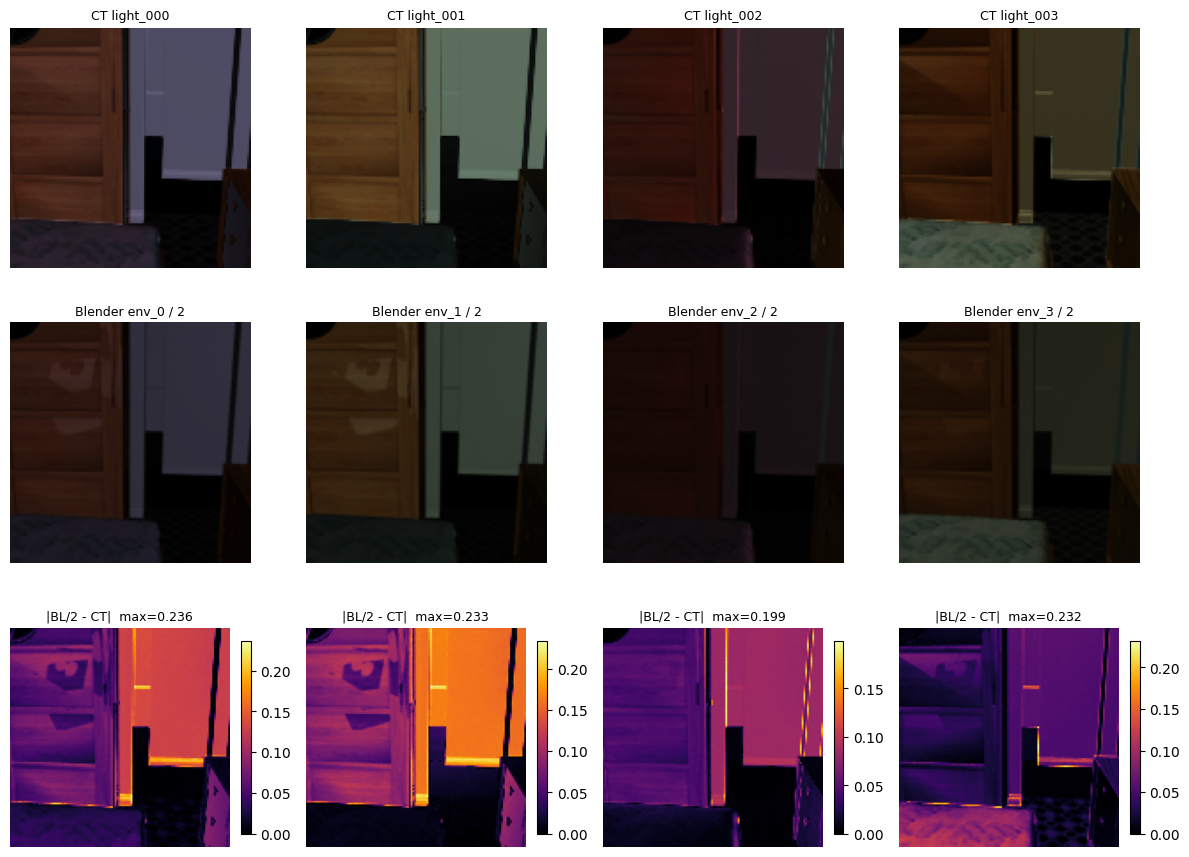

In [3]:
# visual: CT render, Blender render (/2 for comparable brightness), abs difference
show_n = 4
fig, axes = plt.subplots(3, show_n, figsize=(3.0 * show_n, 9))
for c in range(show_n):
    ct, bl = np.asarray(ct_imgs[c]), bl_exr[c]
    axes[0, c].imshow(np.clip(ct, 0, 1));            axes[0, c].set_title(f'CT light_{c:03d}', fontsize=9)
    axes[1, c].imshow(np.clip(bl / ENV_STRENGTH, 0, 1)); axes[1, c].set_title(f'Blender env_{c} / 2', fontsize=9)
    d = np.abs(bl / ENV_STRENGTH - ct).mean(-1) * mask_np
    im = axes[2, c].imshow(d, cmap='inferno'); axes[2, c].set_title(f'|BL/2 - CT|  max={d.max():.3f}', fontsize=9)
    plt.colorbar(im, ax=axes[2, c], fraction=0.04)
for ax in axes.flat: ax.axis('off')
plt.tight_layout(); plt.show()

## E1 — Forward-model consistency with GT intrinsics + GT lighting

No optimization anywhere here: we shade the **GT** albedo/roughness/metallic with the **known**
lighting of light *i* and compare against the Blender EXR. Any residual is pure forward-model error —
exactly the error floor the decomposition has to absorb by distorting intrinsics/lighting.

Variants (all with GT intrinsics):

| variant | lighting | shader | isolates |
|---|---|---|---|
| `sanity` | signed SH | `shade_ct_sh` vs **CT npy** | should be ≈ 0 (inverse crime check) |
| `sh_x2` | signed SH × 2 | `shade_ct_sh` | the model actually used in decomposition |
| `env_signed_x2` | signed SH env map × 2 | `shade_ct_env` | SH-filter vs explicit integration |
| `env_rect_x2` | **rectified** SH env × 2 | `shade_ct_env` | + rectification (`max(·,0)`) |
| `env_png_x2` | the actual 8-bit PNG × 2 (**exactly Blender's input**) | `shade_ct_env` | + quantization; remaining gap vs Blender ⇒ BSDF/geometry (H4/H5) |

`ls_scale` = per-light least-squares scale model→Blender. If a *constant* scale fixed everything,
the decomposition could absorb it in lighting ⇔ albedo scale; a *varying* scale / high scaled-RMSE cannot be absorbed.

In [4]:
def render_ct_sh_fwd(sh_np, light_scale=1.0, dtype=torch.float64, rough_override=None):
    t = T(dtype)
    sh_t = torch.from_numpy(np.asarray(sh_np)).to(DEVICE, dtype) * light_scale
    ro = t['ro'] if rough_override is None else torch.full_like(t['ro'], rough_override)
    with torch.no_grad():
        out = shade_ct_sh(t['V'], t['N'], t['ab'], sh_t,
                          metallic=t['me'], roughness=ro, lut=t['lut'])
    return scatter(out)

def render_ct_env_fwd(env_img, light_scale=1.0, dtype=torch.float64, rough_override=None):
    t = T(dtype)
    em = EnvMap(np.asarray(env_img, np.float32))
    pix  = torch.from_numpy(em._image_flat).to(DEVICE, dtype) * light_scale
    dirs = torch.from_numpy(em._dirs).to(DEVICE, dtype)
    dw   = torch.from_numpy(em._solid_angles).to(DEVICE, dtype)
    ro = t['ro'] if rough_override is None else torch.full_like(t['ro'], rough_override)
    with torch.no_grad():
        out = shade_ct_env(t['V'], t['N'], t['ab'], pix, dirs, dw,
                           metallic=t['me'], roughness=ro)
    return scatter(out)

def sh_env_signed_img(coeffs, resolution=64):
    '''SH -> equirect radiance WITHOUT the max(.,0) rectification of EnvMap.from_sh.'''
    H_, W_ = resolution // 2, resolution
    theta = np.pi * (np.arange(H_, dtype=np.float32) + 0.5) / H_
    phi   = 2 * np.pi * (np.arange(W_, dtype=np.float32) + 0.5) / W_ - np.pi
    st = np.sin(theta)[:, None]
    dirs = np.stack([st * np.cos(phi)[None, :],
                     np.broadcast_to(np.cos(theta)[:, None], (H_, W_)).copy(),
                     st * np.sin(phi)[None, :]], -1)
    return build_sh_basis(dirs) @ np.asarray(coeffs, np.float32)

recs, models_sh2, models_png = [], [], []
for i in range(N_CMP):
    tgt = bl_exr[i]
    signed = sh_env_signed_img(sh_gt[i])
    outs = {
        'sanity: sh vs CT npy': (render_ct_sh_fwd(sh_gt[i]), np.asarray(ct_imgs[i], np.float64)),
        'sh_x2 vs BL':          (render_ct_sh_fwd(sh_gt[i], ENV_STRENGTH), tgt),
        'env_signed_x2 vs BL':  (render_ct_env_fwd(signed, ENV_STRENGTH), tgt),
        'env_rect_x2 vs BL':    (render_ct_env_fwd(np.maximum(signed, 0.0), ENV_STRENGTH), tgt),
        'env_png_x2 vs BL':     (render_ct_env_fwd(env_png[i], ENV_STRENGTH), tgt),
    }
    models_sh2.append(outs['sh_x2 vs BL'][0])
    models_png.append(outs['env_png_x2 vs BL'][0])
    for name, (mdl, target) in outs.items():
        s, sr = opt_scale_rmse(mdl, target)
        recs.append(dict(variant=name, light=i, rmse=rmse(mdl, target),
                         ls_scale=float(s.mean()), rmse_after_scale=sr,
                         corr=pearson(mdl, target)))

df1 = pd.DataFrame(recs)
agg = df1.groupby('variant', sort=False).agg(
    rmse_mean=('rmse', 'mean'), rmse_max=('rmse', 'max'),
    scale_mean=('ls_scale', 'mean'), scale_std=('ls_scale', 'std'),
    rmse_scaled_mean=('rmse_after_scale', 'mean'), corr_mean=('corr', 'mean'))
print(agg.to_string())
print(f"\nreference points:  8-bit quantization floor ~{1/(255*np.sqrt(12)):.5f}   "
      f"| user's final recon RMSE on CT data ~0.0075, on Blender data ~0.02-0.04")

                      rmse_mean  rmse_max  scale_mean  scale_std  rmse_scaled_mean  corr_mean
variant                                                                                      
sanity: sh vs CT npy     0.0000    0.0000      1.0000     0.0000            0.0000     1.0000
sh_x2 vs BL              0.1521    0.2330      0.5708     0.1153            0.0383     0.9045
env_signed_x2 vs BL      0.1454    0.2144      0.5764     0.0932            0.0369     0.9350
env_rect_x2 vs BL        0.1752    0.2284      0.5184     0.0781            0.0255     0.9651
env_png_x2 vs BL         0.1734    0.2262      0.5214     0.0783            0.0255     0.9652

reference points:  8-bit quantization floor ~0.00113   | user's final recon RMSE on CT data ~0.0075, on Blender data ~0.02-0.04


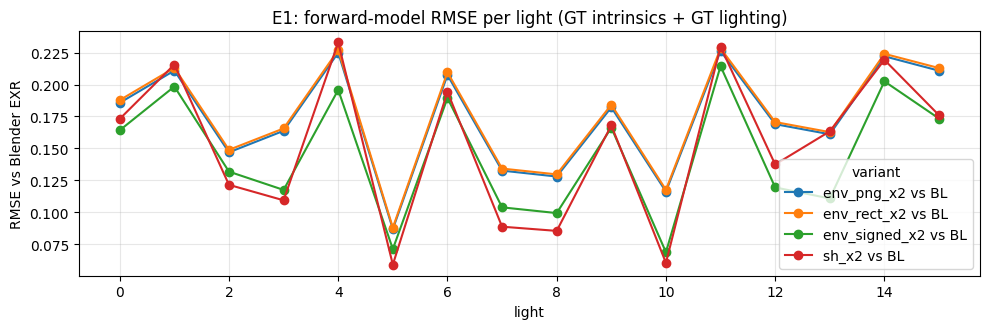

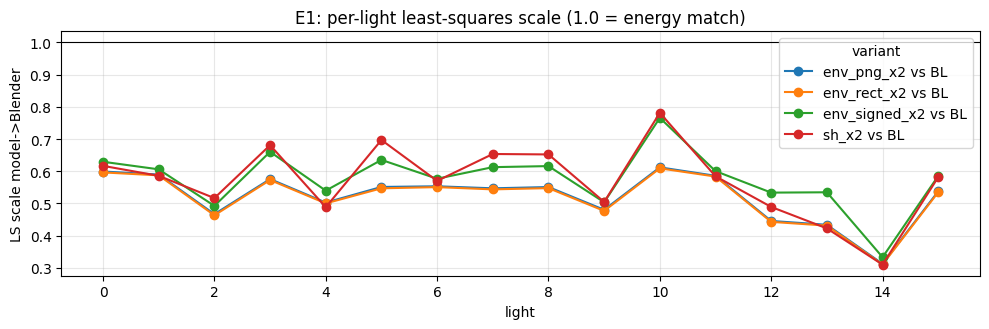

In [5]:
# per-light view of the same numbers (is the gap uniform across lights?)
piv = df1[df1.variant != 'sanity: sh vs CT npy'].pivot(index='light', columns='variant', values='rmse')
piv.plot(figsize=(10, 3.4), marker='o')
plt.ylabel('RMSE vs Blender EXR'); plt.title('E1: forward-model RMSE per light (GT intrinsics + GT lighting)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

pivs = df1[df1.variant != 'sanity: sh vs CT npy'].pivot(index='light', columns='variant', values='ls_scale')
pivs.plot(figsize=(10, 3.4), marker='o')
plt.axhline(1.0, color='k', lw=0.8)
plt.ylabel('LS scale model->Blender'); plt.title('E1: per-light least-squares scale (1.0 = energy match)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

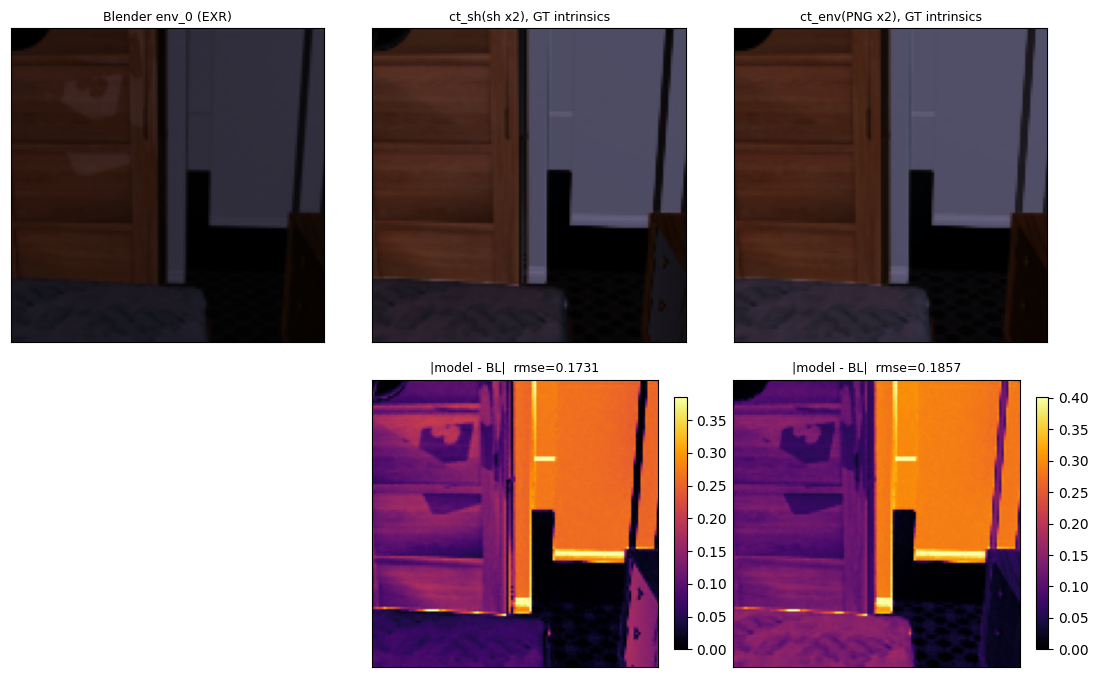

In [6]:
# visual for one light: Blender vs the two extreme model variants + residuals
i = 0
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
panels = [('Blender env_0 (EXR)', bl_exr[i]),
          ('ct_sh(sh x2), GT intrinsics', models_sh2[i]),
          ('ct_env(PNG x2), GT intrinsics', models_png[i])]
for c, (title, img) in enumerate(panels):
    axes[0, c].imshow(np.clip(img / ENV_STRENGTH, 0, 1)); axes[0, c].set_title(title, fontsize=9)
    if c == 0:
        axes[1, c].axis('off'); continue
    d = np.abs(img - bl_exr[i]).mean(-1) * mask_np
    im = axes[1, c].imshow(d, cmap='inferno', vmax=np.percentile(d, 99.5))
    axes[1, c].set_title(f'|model - BL|  rmse={rmse(img, bl_exr[i]):.4f}', fontsize=9)
    plt.colorbar(im, ax=axes[1, c], fraction=0.04)
for ax in axes.flat: ax.axis('off') if not ax.images else ax.set_xticks([]) or ax.set_yticks([])
plt.tight_layout(); plt.show()

## E2 — Where does the residual live? (tests the low-roughness hypothesis)

Per-pixel |model − Blender| averaged over the 16 lights, binned by **GT roughness**
and split by metallic. If the user's low-roughness suspicion is right, the residual
should blow up in the lowest-roughness bins — and we can check whether that residual is
*numerical* (E3) or *structural* (rectified-lighting / BSDF mismatch).

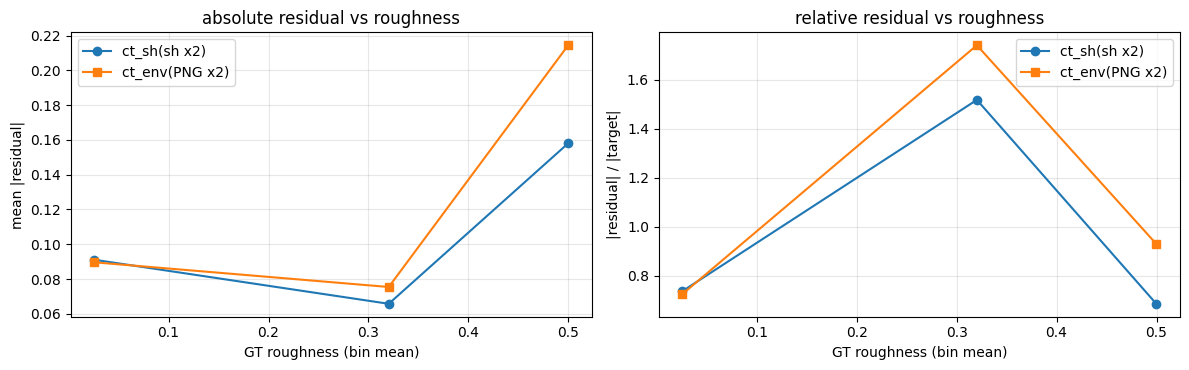

metallic split (mean |residual|, ct_sh model):
  metallic > 0.5     n=   878  abs=0.0639  rel=4.924
  dielectric <= 0.5  n= 14498  abs=0.1201  rel=0.704

low-roughness (r < 0.15) vs rest (ct_sh model):
  r < 0.15           n=  6900  abs=0.0938  rel=0.704
  r >= 0.15          n=  8476  abs=0.1357  rel=0.734


In [7]:
res_sh  = np.stack([np.abs(masked(models_sh2[i]) - masked(bl_exr[i])).mean(-1) for i in range(N_CMP)]).mean(0)
res_png = np.stack([np.abs(masked(models_png[i]) - masked(bl_exr[i])).mean(-1) for i in range(N_CMP)]).mean(0)
tgt_mag = np.stack([masked(bl_exr[i]).mean(-1) for i in range(N_CMP)]).mean(0)
rr = masked(np.repeat(gt_rough, 3, axis=-1)).mean(-1)
mm = masked(np.repeat(gt_metal, 3, axis=-1)).mean(-1)

edges = np.unique(np.quantile(rr, np.linspace(0, 1, 13)))
bin_id = np.clip(np.digitize(rr, edges) - 1, 0, len(edges) - 2)
centers, abs_sh, abs_png, rel_sh, rel_png, counts = [], [], [], [], [], []
for b in range(len(edges) - 1):
    sel = bin_id == b
    if sel.sum() < 20: continue
    centers.append(rr[sel].mean()); counts.append(int(sel.sum()))
    abs_sh.append(res_sh[sel].mean());  abs_png.append(res_png[sel].mean())
    rel_sh.append(res_sh[sel].mean() / max(tgt_mag[sel].mean(), 1e-9))
    rel_png.append(res_png[sel].mean() / max(tgt_mag[sel].mean(), 1e-9))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(centers, abs_sh, 'o-', label='ct_sh(sh x2)')
ax[0].plot(centers, abs_png, 's-', label='ct_env(PNG x2)')
ax[0].set_xlabel('GT roughness (bin mean)'); ax[0].set_ylabel('mean |residual|')
ax[0].set_title('absolute residual vs roughness'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(centers, rel_sh, 'o-', label='ct_sh(sh x2)')
ax[1].plot(centers, rel_png, 's-', label='ct_env(PNG x2)')
ax[1].set_xlabel('GT roughness (bin mean)'); ax[1].set_ylabel('|residual| / |target|')
ax[1].set_title('relative residual vs roughness'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('metallic split (mean |residual|, ct_sh model):')
for name, sel in [('metallic > 0.5', mm > 0.5), ('dielectric <= 0.5', mm <= 0.5)]:
    print(f'  {name:18s} n={sel.sum():6d}  abs={res_sh[sel].mean():.4f}  '
          f'rel={res_sh[sel].mean()/max(tgt_mag[sel].mean(),1e-9):.3f}')

print('\nlow-roughness (r < 0.15) vs rest (ct_sh model):')
for name, sel in [('r < 0.15', rr < 0.15), ('r >= 0.15', rr >= 0.15)]:
    print(f'  {name:18s} n={sel.sum():6d}  abs={res_sh[sel].mean():.4f}  '
          f'rel={res_sh[sel].mean()/max(tgt_mag[sel].mean(),1e-9):.3f}')

## E3 — Numerical precision & quantization floors (tests H1/H2 directly)

1. Run the exact same forward pass in float32 and float64 (including a forced-roughness sweep
   down to 0.0). If numerics were the problem, the f32/f64 difference would be comparable to the
   observed residuals (~1e-2). If it is ~1e-6, H1 is refuted — float32 already suffices,
   and float64 cannot be the missing ingredient.
2. Quantify what the 8-bit PNG dataset (`3dfront-dataset-env`, the plotted run) loses:
   clipping >1 plus *truncating* (not rounding) quantization.

In [8]:
print('float32 vs float64 forward difference (GT intrinsics, light 0, lighting x2):')
print(f'{"roughness":>12s} {"ct_sh max|Δ|":>14s} {"ct_sh rmse":>12s} {"ct_env max|Δ|":>14s} {"ct_env rmse":>12s}')
for ro in [None, 0.0, 0.01, 0.05, 0.1, 0.3]:
    a64 = render_ct_sh_fwd(sh_gt[0], ENV_STRENGTH, torch.float64, ro)
    a32 = render_ct_sh_fwd(sh_gt[0], ENV_STRENGTH, torch.float32, ro)
    e64 = render_ct_env_fwd(env_png[0], ENV_STRENGTH, torch.float64, ro)
    e32 = render_ct_env_fwd(env_png[0], ENV_STRENGTH, torch.float32, ro)
    lab = 'GT map' if ro is None else f'{ro:.2f}'
    print(f'{lab:>12s} {np.abs(a64-a32).max():14.2e} {rmse(a64,a32):12.2e} '
          f'{np.abs(e64-e32).max():14.2e} {rmse(e64,e32):12.2e}')

print('\nquantization / clipping of the Blender image data:')
q_round = [rmse(np.round(np.clip(b,0,1)*255)/255, b) for b in bl_exr]
q_trunc = [rmse(np.floor(np.clip(b,0,1)*255)/255, b) for b in bl_exr]   # what save_png actually does
q_ds    = [rmse(bl_png[i], bl_exr[i]) for i in range(N_CMP)]
clip_frac = [float((masked(b) > 1.0).mean()) for b in bl_exr]
print(f'  ideal 8-bit rounding floor:        {1/(255*np.sqrt(12)):.5f}')
print(f'  round-quantized EXR vs EXR (mean): {np.mean(q_round):.5f}')
print(f'  trunc-quantized EXR vs EXR (mean): {np.mean(q_trunc):.5f}   <- save_png truncates')
print(f'  actual dataset PNG vs EXR (mean):  {np.mean(q_ds):.5f}')
print(f'  fraction of pixels clipped (>1):   {np.mean(clip_frac)*100:.3f}%')
print('\n  -> compare these floors against the E1 model-gap RMSE (~10-50x larger).')

float32 vs float64 forward difference (GT intrinsics, light 0, lighting x2):
   roughness   ct_sh max|Δ|   ct_sh rmse  ct_env max|Δ|  ct_env rmse


      GT map       2.31e-07     5.41e-08       7.25e-05     6.03e-07


        0.00       2.18e-07     5.34e-08       3.10e-07     4.75e-08


        0.01       2.28e-07     5.38e-08       1.11e-05     1.03e-07


        0.05       2.21e-07     5.34e-08       7.01e-03     5.69e-05


        0.10       2.31e-07     5.35e-08       8.26e-02     7.74e-04


        0.30       2.26e-07     5.37e-08       1.56e-03     1.45e-05

quantization / clipping of the Blender image data:
  ideal 8-bit rounding floor:        0.00113
  round-quantized EXR vs EXR (mean): 0.00000
  trunc-quantized EXR vs EXR (mean): 0.00000   <- save_png truncates
  actual dataset PNG vs EXR (mean):  0.00000
  fraction of pixels clipped (>1):   0.000%

  -> compare these floors against the E1 model-gap RMSE (~10-50x larger).


## E4 — Best-achievable fit with a *free* SH light and **GT intrinsics**

Now let the per-image SH lighting be optimized (as in decomposition) but keep albedo,
roughness and metallic clamped to GT. This answers: *if the intrinsics were perfect,
how well can the signed-order-2-SH lighting model explain each dataset?*

- On **CT data** this must reach ≈ 0 (the data was generated by this very model).
- On **Blender data** the remaining error is the irreducible model gap (H3+H4+H5 combined)
  that the full decomposition instead absorbs by corrupting albedo/roughness/metallic.

In [9]:
def fit_sh_only(images, n_iter=100, label=''):
    cfg = {**DEFAULT_CFG, 'n_iter': n_iter, 'lbfgs_max_iter': 20, 'log_every': 25}
    print(f'--- SH-only fit: {label} ({len(images)} images) ---')
    albedo, sh_out, met, rou, shadings, history, elapsed = _optimize_ct_sh(
        images, normals_hw, frag_pos_hw, mask_hw, cam_pos,
        gt_metal, gt_rough, cfg,
        gt_albedo=gt_albedo, opt_params=frozenset({'sh'}),
    )
    per_img = [rmse(s, img) for s, img in zip(shadings, images)]
    print(f'  final loss={history[-1]:.3e}  recon RMSE mean={np.mean(per_img):.4f} '
          f' max={np.max(per_img):.4f}  ({elapsed:.0f}s)')
    return sh_out, shadings, per_img

sh_fit_ct, shad_ct, per_ct = fit_sh_only([np.asarray(im) for im in ct_imgs[:N_CMP]], label='CT data (control)')
sh_fit_bl, shad_bl, per_bl = fit_sh_only(bl_exr, label='Blender EXR data')

--- SH-only fit: CT data (control) (16 images) ---


  [init]          loss=5.984e-01  data=5.984e-01  metallic=0.062  roughness=0.248


  [   0]    1.7s  loss=2.064e-03  data=2.064e-03  metallic=0.062  roughness=0.248


  [  25]   49.4s  loss=3.640e-04  data=3.640e-04  metallic=0.062  roughness=0.248


  [  50]   53.6s  loss=3.640e-04  data=3.640e-04  metallic=0.062  roughness=0.248


...

  [   0]    1.6s  loss=5.413e-03  data=5.413e-03  metallic=0.062  roughness=0.248


  [  25]   41.7s  loss=4.581e-03  data=4.581e-03  metallic=0.062  roughness=0.248


  [  50]   45.0s  loss=4.581e-03  data=4.581e-03  metallic=0.062  roughness=0.248


  [  75]   48.6s  loss=4.581e-03  data=4.581e-03  metallic=0.062  roughness=0.248


  final loss=4.581e-03  recon RMSE mean=0.0232  max=0.0305  (52s)


CT      : cosine(fit, GT SH)    mean=0.8768  |  LS scale fit->GT mean=0.808
Blender : cosine(fit, 2*GT SH)  mean=0.7415  |  LS scale fit->GT mean=1.685


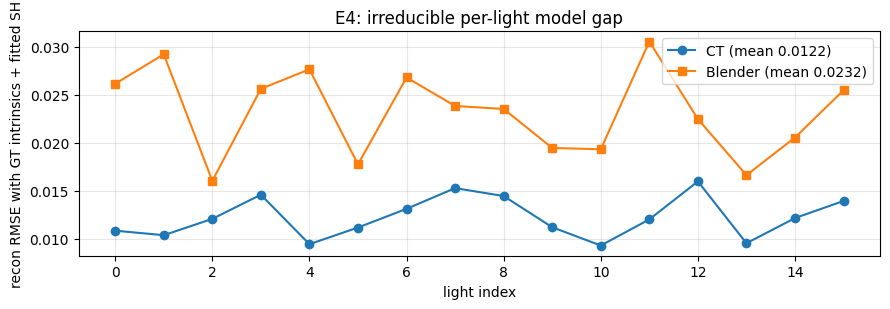

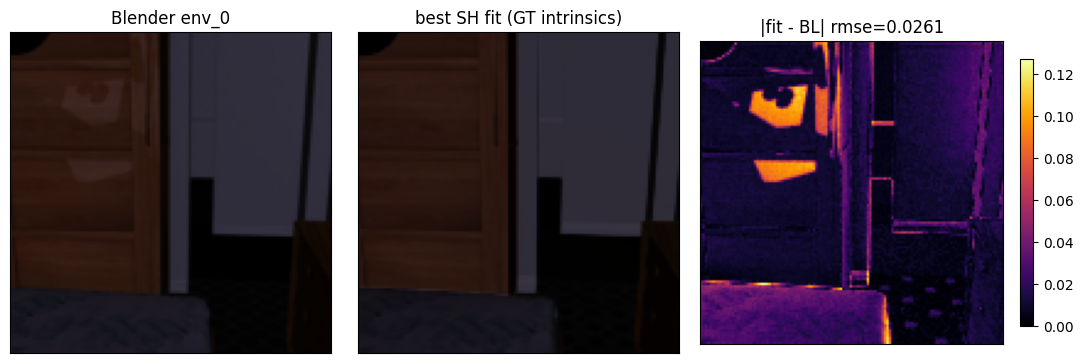

In [10]:
# How close is the fitted SH to the known GT SH (x2 for Blender)?
def sh_similarity(sh_fit, sh_ref_scaled):
    sims, scales = [], []
    for k in range(len(sh_ref_scaled)):
        a, b = sh_fit[k].ravel(), np.asarray(sh_ref_scaled[k], np.float32).ravel()
        scales.append(float((a @ b) / max(a @ a, 1e-12)))
        sims.append(float((a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)))
    return np.array(sims), np.array(scales)

sims_ct, sc_ct = sh_similarity(sh_fit_ct, [s for s in sh_gt[:N_CMP]])
sims_bl, sc_bl = sh_similarity(sh_fit_bl, [s * ENV_STRENGTH for s in sh_gt[:N_CMP]])
print(f'CT      : cosine(fit, GT SH)    mean={sims_ct.mean():.4f}  |  LS scale fit->GT mean={sc_ct.mean():.3f}')
print(f'Blender : cosine(fit, 2*GT SH)  mean={sims_bl.mean():.4f}  |  LS scale fit->GT mean={sc_bl.mean():.3f}')

plt.figure(figsize=(9, 3.2))
plt.plot(per_ct, 'o-', label=f'CT (mean {np.mean(per_ct):.4f})')
plt.plot(per_bl, 's-', label=f'Blender (mean {np.mean(per_bl):.4f})')
plt.xlabel('light index'); plt.ylabel('recon RMSE with GT intrinsics + fitted SH')
plt.title('E4: irreducible per-light model gap'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

i = 0
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
axes[0].imshow(np.clip(bl_exr[i] / ENV_STRENGTH, 0, 1)); axes[0].set_title('Blender env_0')
axes[1].imshow(np.clip(shad_bl[i] / ENV_STRENGTH, 0, 1)); axes[1].set_title('best SH fit (GT intrinsics)')
d = np.abs(shad_bl[i] - bl_exr[i]).mean(-1) * mask_np
im = axes[2].imshow(d, cmap='inferno'); axes[2].set_title(f'|fit - BL| rmse={per_bl[i]:.4f}')
plt.colorbar(im, ax=axes[2], fraction=0.04)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## E5 — Decomposition attribution (small runs, 16 images, user's config)

Three decompositions with the *same* settings the user runs
(sigmoid metallic/roughness, TV 1e-3, metallic-binarize 1e-3, init_roughness_zero, float64, L-BFGS):

| run | data | lighting |
|---|---|---|
| **A control** | CT `.npy` | free |
| **B full** | Blender EXR | free |
| **C frozen light** | Blender EXR | **fixed to 2 × GT SH** (only intrinsics optimized) |

If C recovers materials much better than B, the failure mode is lighting/albedo shell-game
(the SH lights absorbing model mismatch and dragging albedo scale with them).
If C is as bad as B, the residual is inherently forcing wrong materials.

In [11]:
USER_CFG = {**DEFAULT_CFG, 'n_iter': 200, 'lbfgs_max_iter': 20, 'log_every': 50,
            'lambda_tv': 1e-3, 'lambda_metallic_binarize': 1e-3,
            'tr_metallic': 'sigmoid', 'tr_roughness': 'sigmoid', 'tr_albedo': 'sigmoid',
            'init_roughness_zero': True}

def run_decomp(images, label, gt_sh=None, opt_params=None, n_iter=200):
    cfg = {**USER_CFG, 'n_iter': n_iter}
    print(f'=== E5 run: {label} ===')
    albedo, sh_out, met, rou, shadings, history, elapsed = _optimize_ct_sh(
        images, normals_hw, frag_pos_hw, mask_hw, cam_pos,
        gt_metal, gt_rough, cfg, gt_albedo=gt_albedo,
        gt_sh_coeffs=gt_sh, opt_params=opt_params)
    est = torch.from_numpy(albedo[mask_np]).double()
    gt  = torch.from_numpy(gt_albedo[mask_np]).double()
    armse, scale = _albedo_rmse(est, gt)
    summ = dict(label=label,
                albedo_rmse=float(armse), albedo_scale_mean=float(scale.mean()),
                metallic_rmse=float(np.sqrt(np.mean((met[mask_np] - gt_metal[mask_np])**2))),
                roughness_rmse=float(np.sqrt(np.mean((rou[mask_np] - gt_rough[mask_np])**2))),
                recon_rmse=float(np.mean([rmse(s, im) for s, im in zip(shadings, images)])),
                final_loss=float(history[-1]), elapsed_s=elapsed)
    print('   ', {k: (f'{v:.4f}' if isinstance(v, float) else v) for k, v in summ.items() if k != 'label'})
    return summ, dict(albedo=albedo, scale=scale.numpy(), met=met, rou=rou)

summs, maps = [], {}
s, m = run_decomp([np.asarray(im) for im in ct_imgs[:N_CMP]], 'A: CT data, free lighting (control)')
summs.append(s); maps['A'] = m
s, m = run_decomp(bl_exr, 'B: Blender EXR, free lighting')
summs.append(s); maps['B'] = m
s, m = run_decomp(bl_exr, 'C: Blender EXR, lighting frozen to 2xGT SH',
                  gt_sh=[np.asarray(sh * ENV_STRENGTH, np.float32) for sh in sh_gt[:N_CMP]],
                  opt_params=frozenset({'albedo', 'metallic', 'roughness'}))
summs.append(s); maps['C'] = m

df5 = pd.DataFrame(summs).set_index('label')
print('\n', df5.to_string())

=== E5 run: A: CT data, free lighting (control) ===
  [init]          loss=2.398e-01  data=2.395e-01  metallic=0.500  roughness=0.100


  [   0]    3.1s  loss=2.701e-03  data=2.432e-03  metallic=0.500  roughness=0.100


  [  50]  117.2s  loss=5.625e-04  data=3.566e-04  metallic=0.208  roughness=0.108


  [ 100]  227.2s  loss=1.973e-04  data=1.253e-04  metallic=0.027  roughness=0.125


  [ 150]  351.6s  loss=1.585e-04  data=9.184e-05  metallic=0.023  roughness=0.133


...

  [   0]    0.9s  loss=3.799e-02  data=3.773e-02  metallic=0.191  roughness=0.116


  [  50]   63.8s  loss=2.003e-02  data=1.977e-02  metallic=0.163  roughness=0.929


  [ 100]  121.1s  loss=1.996e-02  data=1.970e-02  metallic=0.149  roughness=0.960


  [ 150]  126.9s  loss=1.996e-02  data=1.970e-02  metallic=0.149  roughness=0.960


    {'albedo_rmse': '0.5436', 'albedo_scale_mean': '0.5560', 'metallic_rmse': '0.3068', 'roughness_rmse': '0.7595', 'recon_rmse': '0.0365', 'final_loss': '0.0200', 'elapsed_s': '128.3011'}

                                             albedo_rmse  albedo_scale_mean  metallic_rmse  roughness_rmse  recon_rmse  final_loss  elapsed_s
label                                                                                                                                       
A: CT data, free lighting (control)              0.0589             1.5058         0.2248          0.2341      0.0114      0.0002   460.6967
B: Blender EXR, free lighting                    0.2766             0.4802         0.2737          0.2734      0.0200      0.0009   420.5900
C: Blender EXR, lighting frozen to 2xGT SH       0.5436             0.5560         0.3068          0.7595      0.0365      0.0200   128.3011


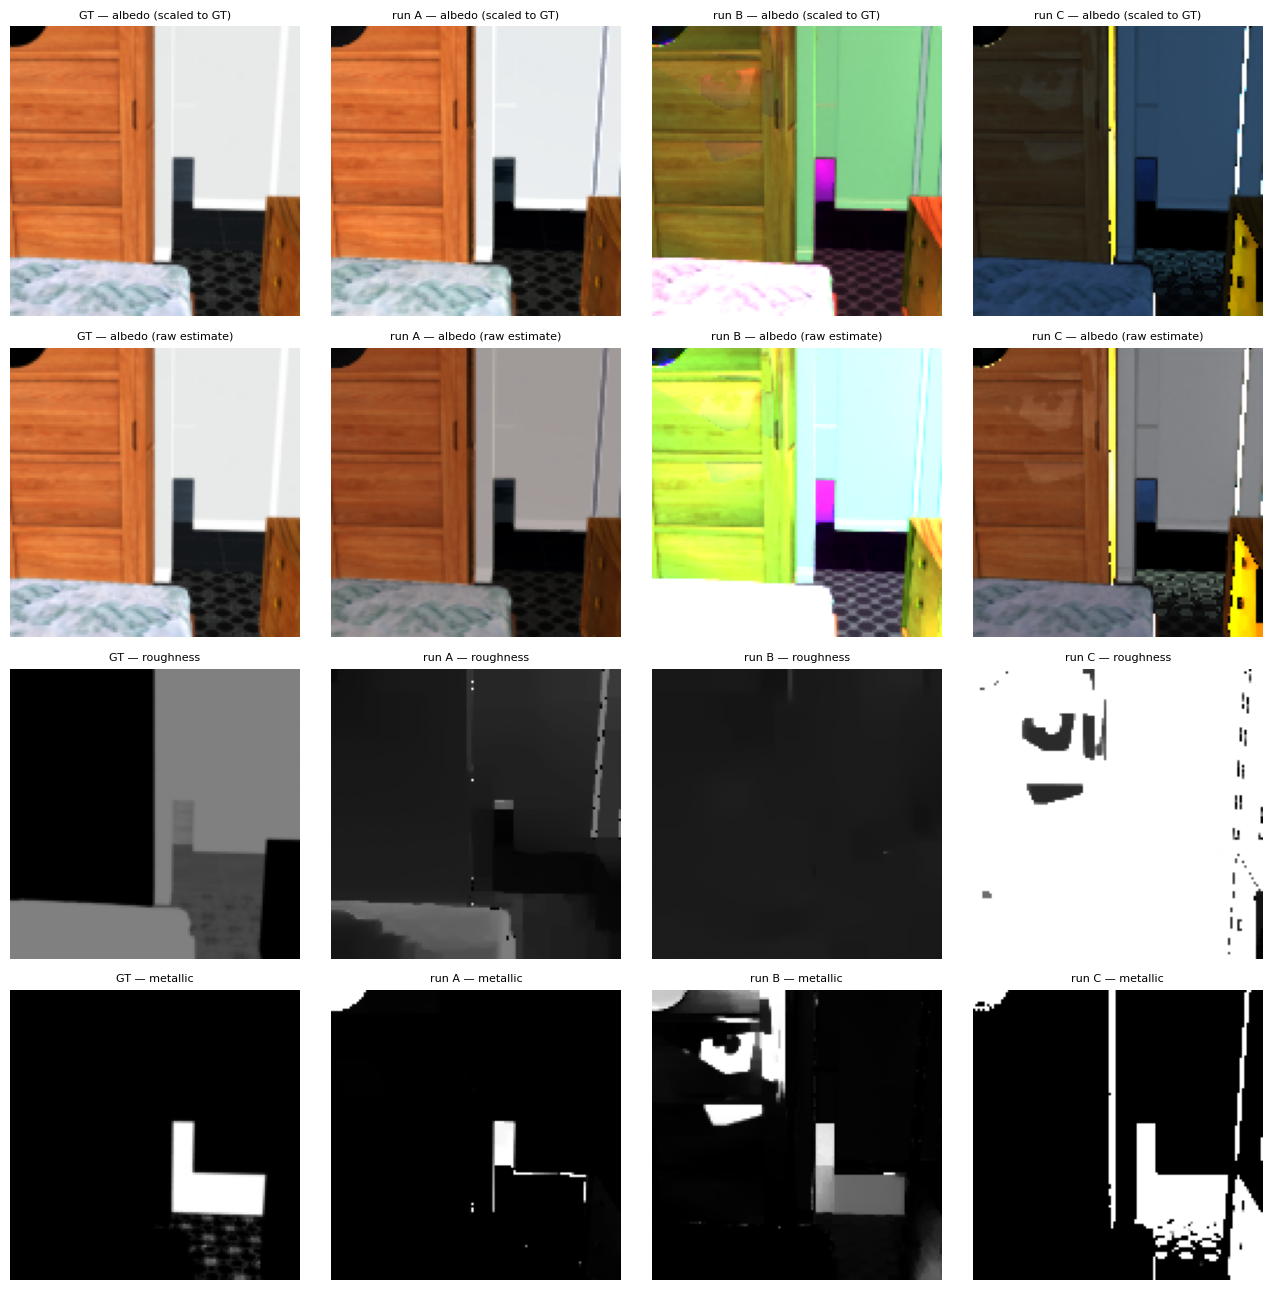

In [12]:
# estimated maps side by side
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
col_titles = ['GT'] + [f'run {k}' for k in ['A', 'B', 'C']]
row_data = [
    ('albedo (scaled to GT)', gt_albedo,
     [np.clip(maps[k]['albedo'] * maps[k]['scale'][None, None, :], 0, 1) * mask_np[:, :, None] for k in 'ABC']),
    ('albedo (raw estimate)', gt_albedo,
     [np.clip(maps[k]['albedo'], 0, 1) * mask_np[:, :, None] for k in 'ABC']),
    ('roughness', gt_rough.squeeze(-1),
     [maps[k]['rou'].squeeze(-1) * mask_np for k in 'ABC']),
    ('metallic', gt_metal.squeeze(-1),
     [maps[k]['met'].squeeze(-1) * mask_np for k in 'ABC']),
]
for r, (name, gt_img, ests) in enumerate(row_data):
    for c, img in enumerate([gt_img] + ests):
        kw = dict(cmap='gray', vmin=0, vmax=1) if img.ndim == 2 else {}
        axes[r, c].imshow(img, **kw)
        axes[r, c].set_title(f'{col_titles[c]} — {name}', fontsize=8)
        axes[r, c].axis('off')
plt.tight_layout(); plt.show()

## Conclusions

*(placeholder — filled in after the notebook has been executed; see the summary that
accompanies this notebook)*